In [1]:
!pip install pandas matplotlib seaborn plotly fredapi lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cf8a4215d7e158080dec5008471d7a8783d2be87d588805f4f7f2bb15ea41af3
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from fredapi import Fred
import plotly.express as px
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

# Features and Target
series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

# Data from FRED
data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index

data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)

data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

Data Overview:
          ds         y  Consumer Price Index  Unemployment Rate  \
0 1992-01-01  159177.0                 138.3                7.3   
1 1992-02-01  159189.0                 138.6                7.4   
2 1992-03-01  158647.0                 139.1                7.4   
3 1992-04-01  159921.0                 139.4                7.4   
4 1992-05-01  160471.0                 139.7                7.6   

   Federal Funds Rate  Personal Consumption Expenditures  \
0                4.03                             4084.7   
1                4.06                             4099.5   
2                3.98                             4117.0   
3                3.73                             4131.5   
4                3.82                             4158.4   

   Real Disposable Personal Income  
0                           7474.8  
1                           7507.2  
2                           7513.8  
3                           7535.0  
4                           7570.2  

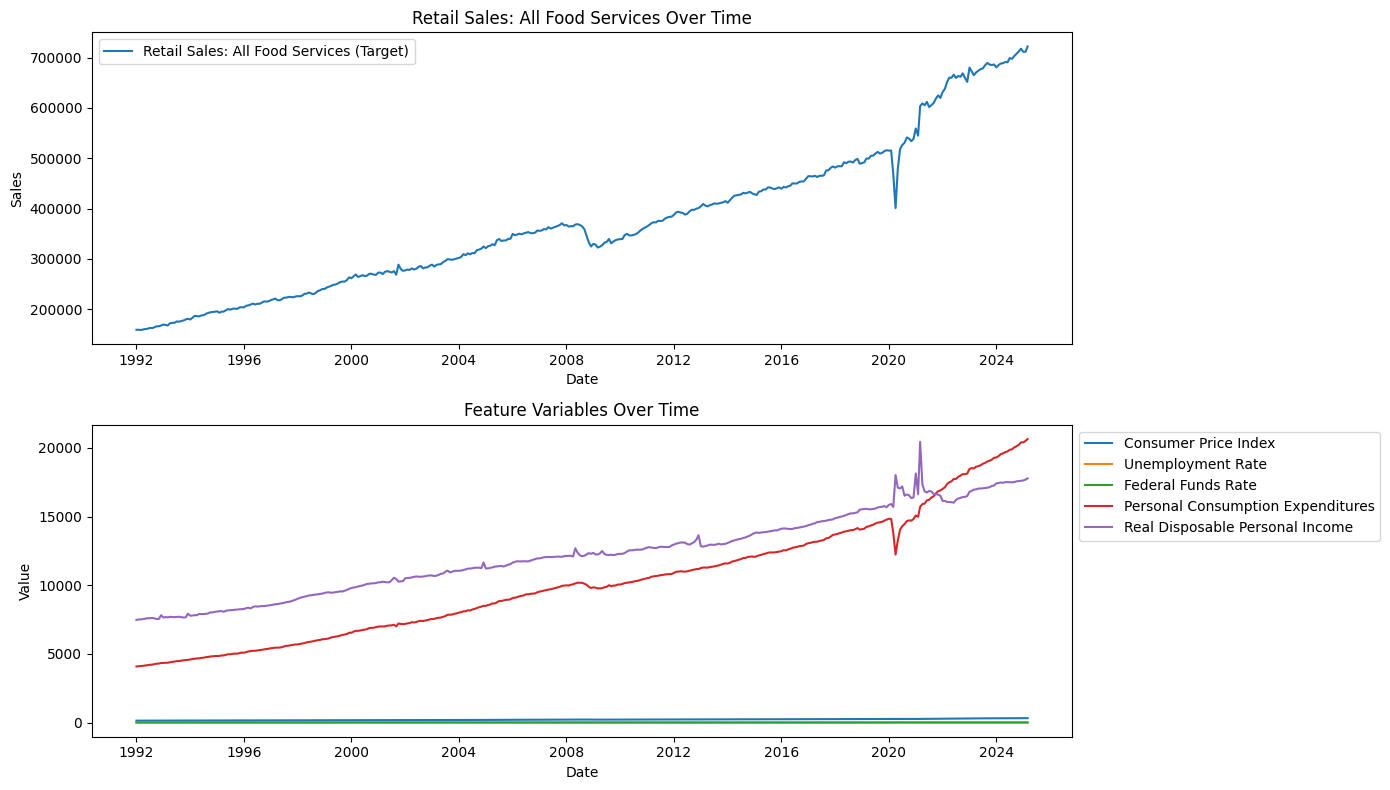


Applying Feature Engineering...
Before starting: Analyzing the current dimensionality of our problem
Original data shape: (399, 7)
Number of original features: 5
After feature engineering: (394, 16)
Number of engineered features: 14

Feature Engineered Data:
          ds         y  Consumer Price Index  Unemployment Rate  \
5 1992-06-01  161205.0                 140.1                7.8   
6 1992-07-01  162855.0                 140.5                7.7   
7 1992-08-01  162412.0                 140.8                7.6   
8 1992-09-01  164361.0                 141.1                7.6   
9 1992-10-01  166063.0                 141.7                7.3   

   Federal Funds Rate  Personal Consumption Expenditures  \
5                3.76                             4177.1   
6                3.25                             4204.8   
7                3.30                             4220.9   
8                3.22                             4255.3   
9                3.10                

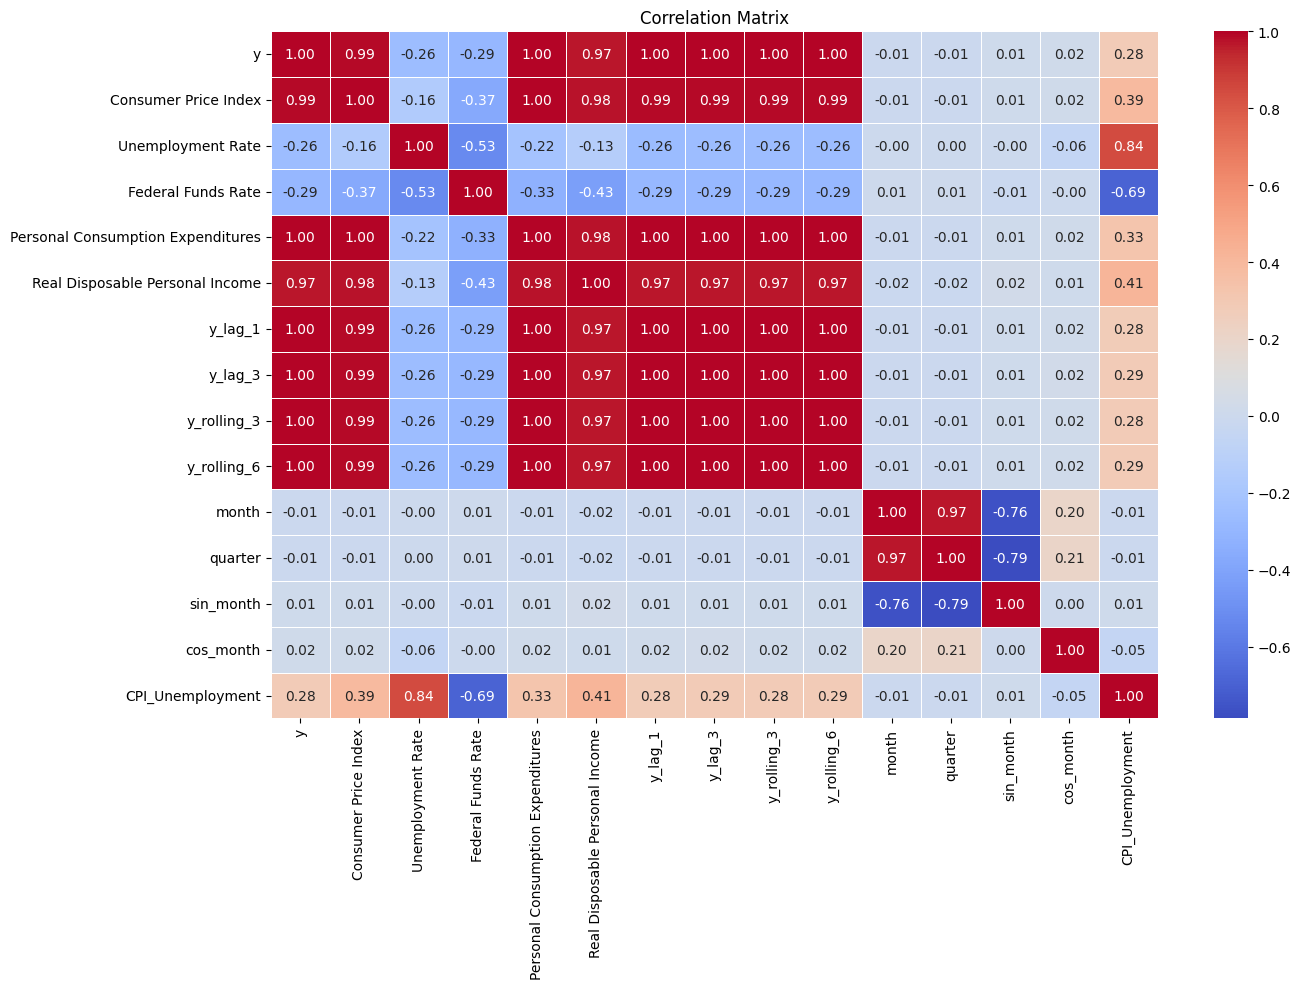

Detected 30 highly correlated feature pairs (|r| > 0.8):
- y and Consumer Price Index: r = 0.9878
- y and Personal Consumption Expenditures: r = 0.9959
- y and Real Disposable Personal Income: r = 0.9678
- y and y_lag_1: r = 0.9986
- y and y_lag_3: r = 0.9964
- y and y_rolling_3: r = 0.9992
- y and y_rolling_6: r = 0.9984
- Consumer Price Index and Personal Consumption Expenditures: r = 0.9962
- Consumer Price Index and Real Disposable Personal Income: r = 0.9776
- Consumer Price Index and y_lag_1: r = 0.9885
- Consumer Price Index and y_lag_3: r = 0.9892
- Consumer Price Index and y_rolling_3: r = 0.9890
- Consumer Price Index and y_rolling_6: r = 0.9902
- Unemployment Rate and CPI_Unemployment: r = 0.8397
- Personal Consumption Expenditures and Real Disposable Personal Income: r = 0.9751
- Personal Consumption Expenditures and y_lag_1: r = 0.9957
- Personal Consumption Expenditures and y_lag_3: r = 0.9952
- Personal Consumption Expenditures and y_rolling_3: r = 0.9963
- Personal Cons

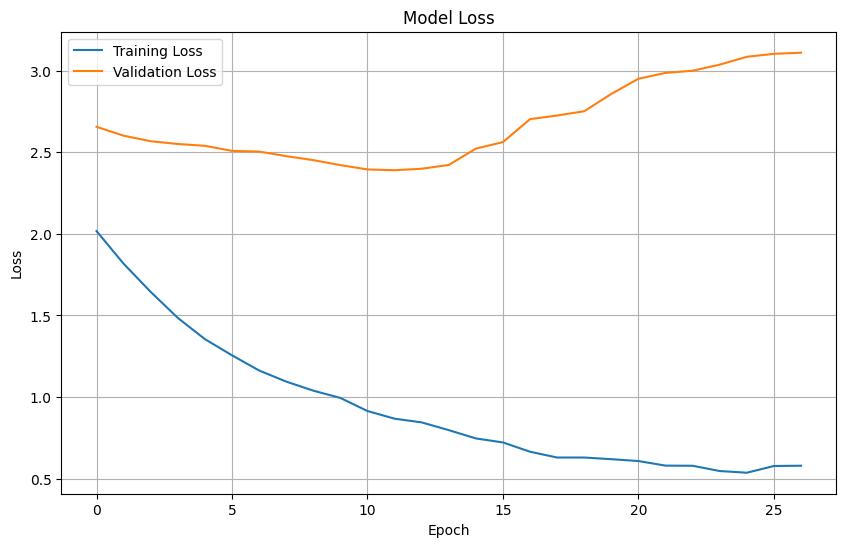

Model Evaluation:
MAE: 358208.8924
RMSE: 358293.8802
R^2: -5766.8541
MAPE: 50.18%


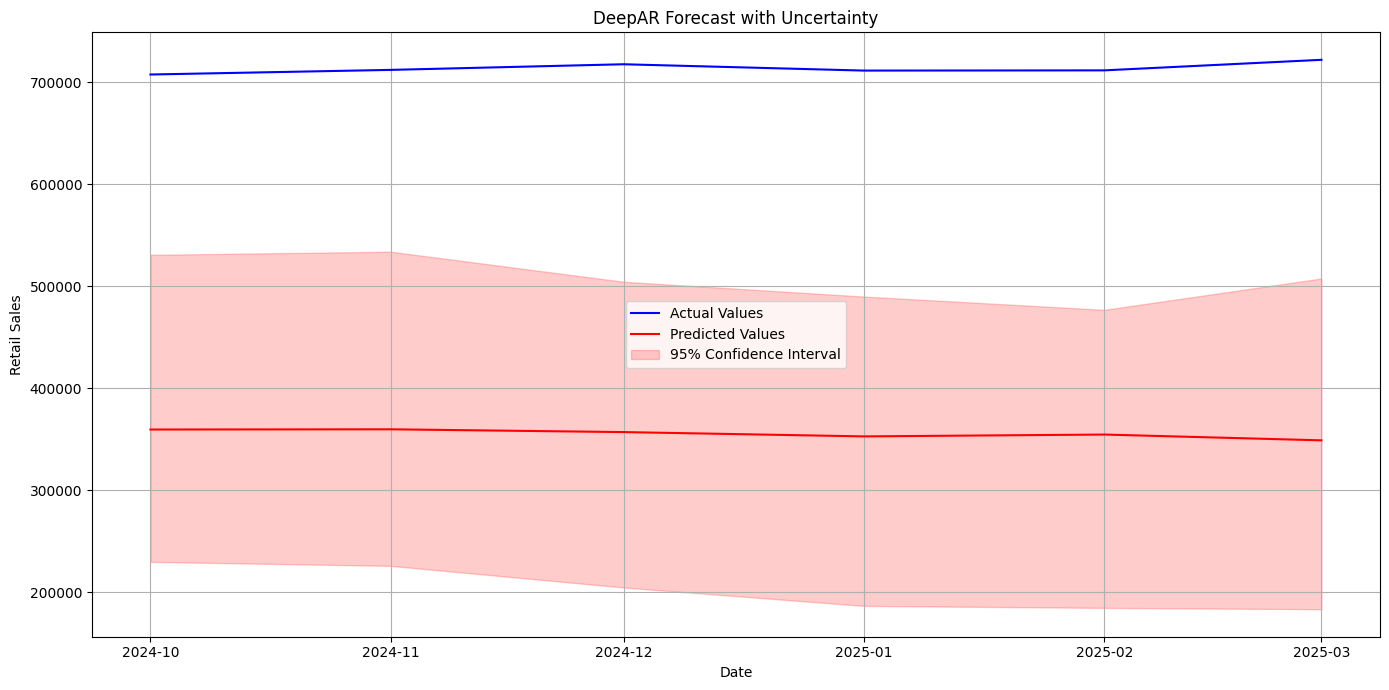

  0%|          | 0/6 [00:00<?, ?it/s]

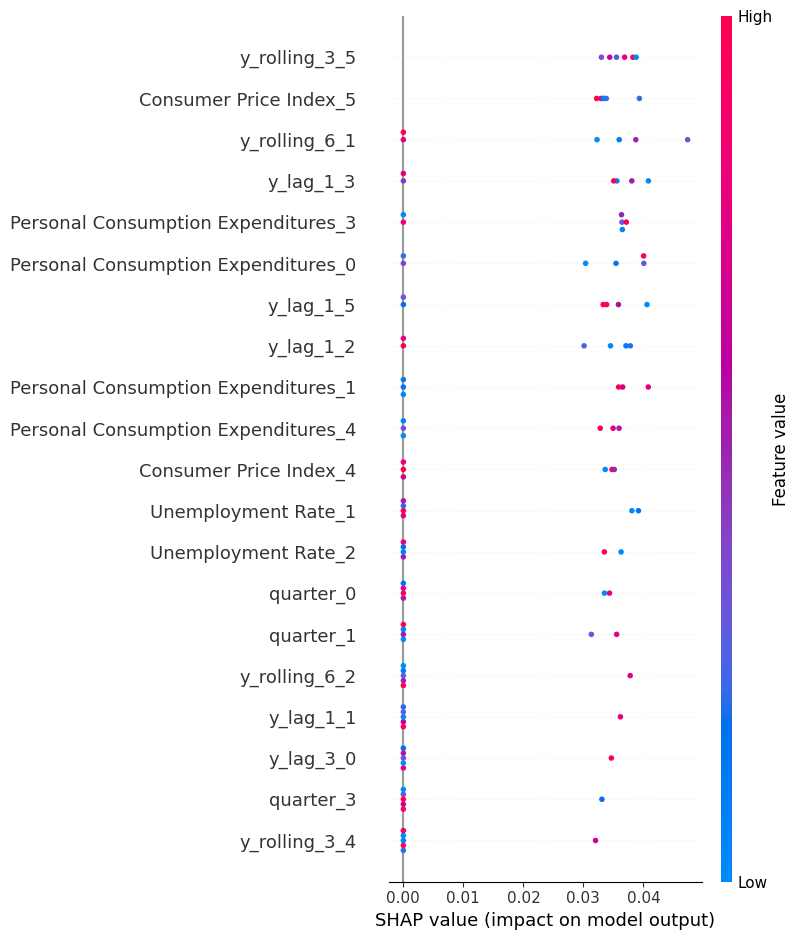

<Figure size 640x480 with 0 Axes>

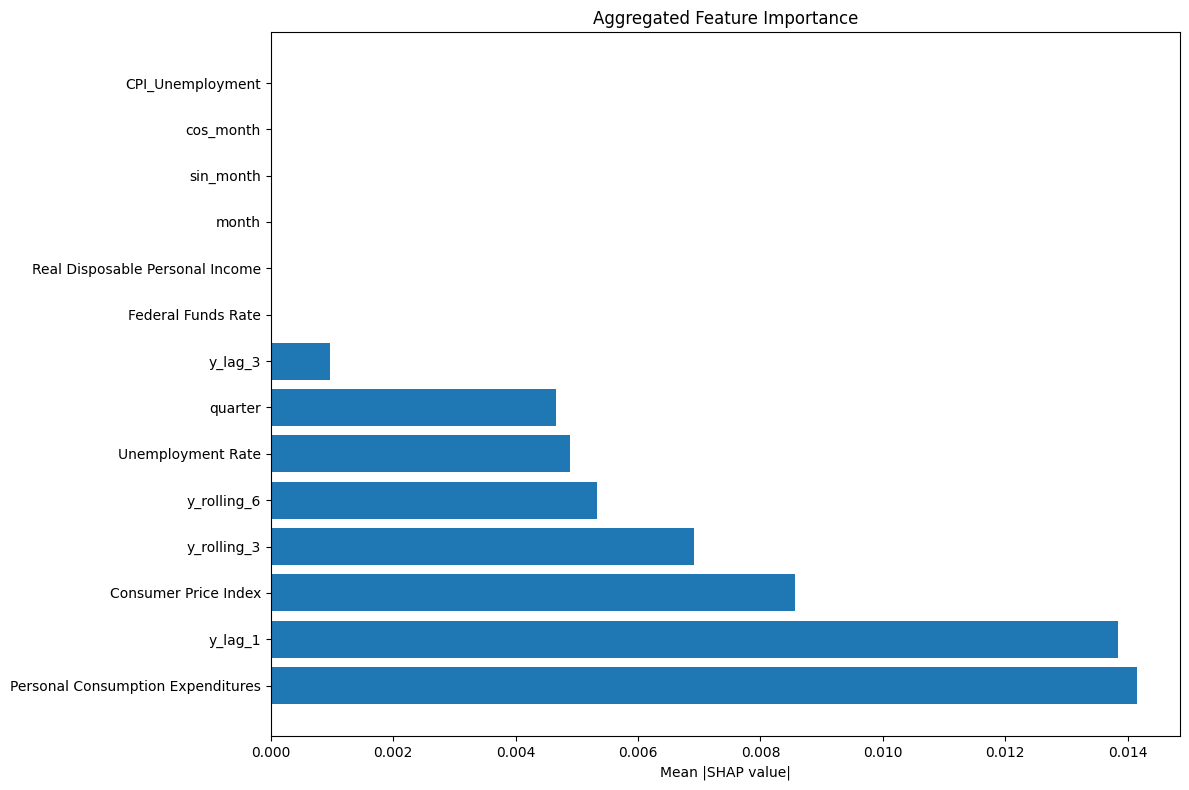

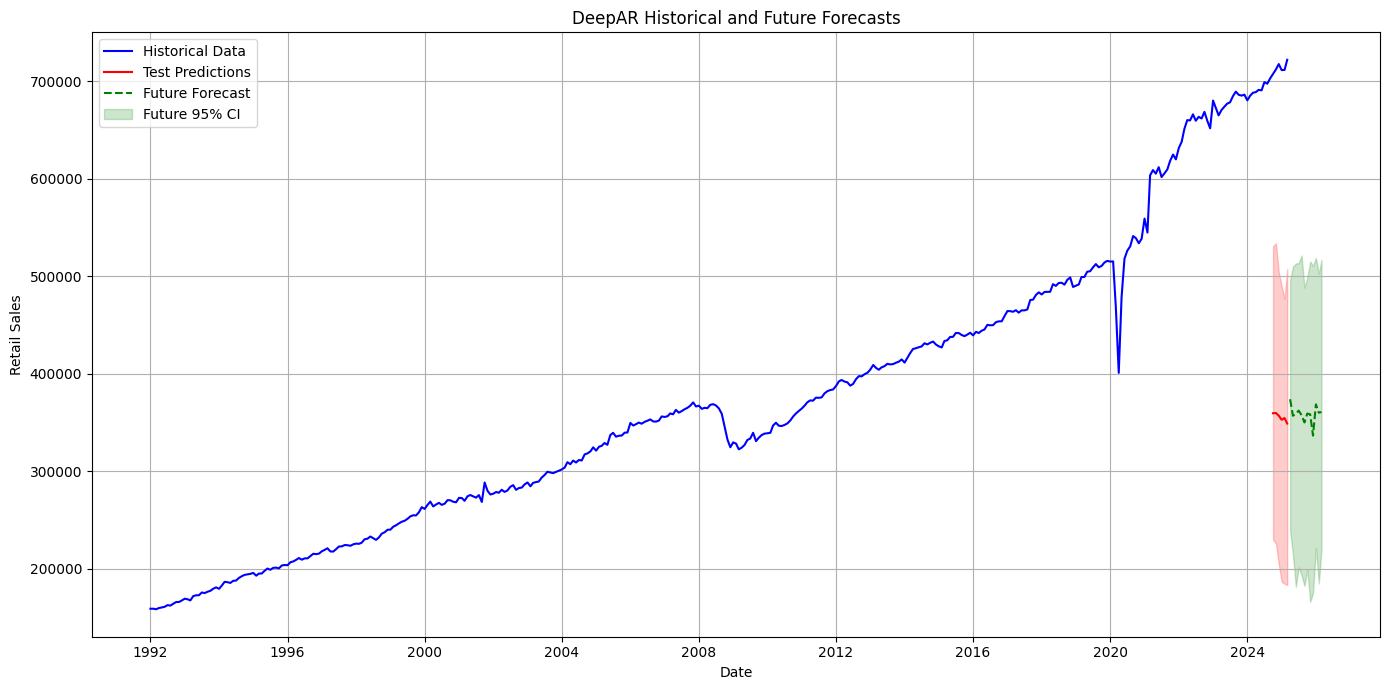


Final Model Evaluation and Insights:
The DeepAR model achieved a MAPE of 50.18%, indicating that on average, predictions were within 50.18% of the actual values.

Top 5 Most Important Features:
1. Personal Consumption Expenditures: 0.0141
2. y_lag_1: 0.0138
3. Consumer Price Index: 0.0086
4. y_rolling_3: 0.0069
5. y_rolling_6: 0.0053


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import shap
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


# 1. Data Exploration and Preprocessing
print("Data Overview:")
print(data.head())
print("Data Shape:", data.shape)
print("Data Info:")
print(data.info())
print(data.describe())

print("Missing Values:")
print(data.isnull().sum())

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(data['ds'], data['y'], label='Retail Sales: All Food Services (Target)')
plt.title('Retail Sales: All Food Services Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.subplot(2, 1, 2)
features = ['Consumer Price Index', 'Unemployment Rate', 'Federal Funds Rate',
           'Personal Consumption Expenditures', 'Real Disposable Personal Income']
for feature in features:
    plt.plot(data['ds'], data[feature], label=feature)
plt.title('Feature Variables Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 2. Feature Engineering
print("\nApplying Feature Engineering...")
print("Before starting: Analyzing the current dimensionality of our problem")
print(f"Original data shape: {data.shape}")
print(f"Number of original features: {len(data.columns) - 2}")  # Excluding 'ds' and 'y'

# Create lag features -but avoiding the curse of dimensionality
def create_lag_features(df, target, lags):
    df_copy = df.copy()
    for lag in lags:
        df_copy[f'{target}_lag_{lag}'] = df_copy[target].shift(lag)
    return df_copy

# Create rolling mean features - to make it informative and less prone to overfitting than raw lags
def create_rolling_features(df, target, windows):
    df_copy = df.copy()
    for window in windows:
        df_copy[f'{target}_rolling_{window}'] = df_copy[target].rolling(window=window).mean()
    return df_copy

# Create time features for seasonality
def create_time_features(df, date_col):
    df_copy = df.copy()
    df_copy['month'] = df_copy[date_col].dt.month
    df_copy['quarter'] = df_copy[date_col].dt.quarter
    df_copy['sin_month'] = np.sin(2 * np.pi * df_copy['month'] / 12)
    df_copy['cos_month'] = np.cos(2 * np.pi * df_copy['month'] / 12)
    return df_copy

# Reduced lag features - most recent are most important
lags = [1, 3]  # Removed 6, 12 to reduce dimensionality
windows = [3, 6]  # Removed 12 to reduce dimensionality

data_featured = create_lag_features(data, 'y', lags)
data_featured = create_rolling_features(data_featured, 'y', windows)
data_featured = create_time_features(data_featured, 'ds')

data_featured['CPI_Unemployment'] = data_featured['Consumer Price Index'] * data_featured['Unemployment Rate']

data_featured = data_featured.dropna()

print(f"After feature engineering: {data_featured.shape}")
print(f"Number of engineered features: {len(data_featured.columns) - 2}")  # Excluding 'ds' and 'y'

print("\nFeature Engineered Data:")
print(data_featured.head())



# 3. Feature Selection and Importance Analysis
print("Performing feature selection to reduce dimensionality...")

# Correlation analysis
plt.figure(figsize=(14, 10))
correlation_matrix = data_featured.drop('ds', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# highly correlated features
high_correlation_threshold = 0.8
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > high_correlation_threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Detected {len(high_corr_pairs)} highly correlated feature pairs (|r| > {high_correlation_threshold}):")
for feat1, feat2, corr in high_corr_pairs:
    print(f"- {feat1} and {feat2}: r = {corr:.4f}")

if high_corr_pairs:
    print("High multicollinearity detected! This can cause model instability and overfitting.")
    print("The correlation matrix for all features (including engineered ones) helps identify this issue.")
    print("Consider removing one feature from each highly correlated pair.")

# correlation with target variable
target_correlations = correlation_matrix['y'].drop('y').sort_values(ascending=False)
print("\nFeature correlations with target variable (Retail Sales):")
for feature, corr in target_correlations.items():
    print(f"- {feature}: {corr:.4f}")

print("Recommended features based on correlation analysis:")
recommended_features = target_correlations[abs(target_correlations) > 0.5].index.tolist()
print(", ".join(recommended_features))

test_size = 12
validation_size = 12  # 1 year for validation

train_data = data_featured.iloc[:-(test_size + validation_size)]
validation_data = data_featured.iloc[-(test_size + validation_size):-test_size]
test_data = data_featured.iloc[-test_size:]

print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {validation_data.shape}")
print(f"Testing Data Shape: {test_data.shape}")

# Analyze if we have enough data for deep learning
print(f"Data split analysis:")
print(f"Training samples: {len(train_data)} - Ideally we'd want 1000+ samples for deep learning")
print(f"Validation samples: {len(validation_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Ratio of features to samples: {len(train_data.columns) / len(train_data):.4f} - Lower is better")

# 5. Data Scaling
features_to_scale = [col for col in train_data.columns if col != 'ds']
scaler = StandardScaler()
train_scaled = train_data.copy()
validation_scaled = validation_data.copy() if 'validation_data' in locals() else None
test_scaled = test_data.copy()

train_scaled[features_to_scale] = scaler.fit_transform(train_data[features_to_scale])

if validation_scaled is not None:
    validation_scaled[features_to_scale] = scaler.transform(validation_data[features_to_scale])
test_scaled[features_to_scale] = scaler.transform(test_data[features_to_scale])

print("Scaling statistics:")
print(f"Mean of scaled training features: {np.mean(train_scaled.drop('ds', axis=1).values):.4f}")
print(f"Std of scaled training features: {np.std(train_scaled.drop('ds', axis=1).values):.4f}")
print(f"Min value in scaled data: {np.min(train_scaled.drop('ds', axis=1).values):.4f}")
print(f"Max value in scaled data: {np.max(train_scaled.drop('ds', axis=1).values):.4f}")

if np.max(np.abs(train_scaled.drop('ds', axis=1).values)) > 10:
    print(" Warning: Extreme values detected after scaling. Consider robust scaling or outlier treatment.")

# 6. Prepare Sequences for DeepAR - With Special Handling for Small Data
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        seq = data.iloc[i:i+seq_length]
        features = seq.drop(['ds', target], axis=1).values
        target_val = data.iloc[i+seq_length][target]
        X.append(features)
        y.append(target_val)
    return np.array(X), np.array(y)

seq_length = 6  # 6 months of data instead of 12 to increase sample size

X_train, y_train = create_sequences(train_scaled, 'y', seq_length)
X_val, y_val = create_sequences(validation_scaled, 'y', seq_length) if 'validation_scaled' in locals() else (None, None)
X_test, y_test = create_sequences(test_scaled, 'y', seq_length)

print(f"\nTraining Sequences Shape: X={X_train.shape}, y={y_train.shape}")
if X_val is not None:
    print(f"Validation Sequences Shape: X={X_val.shape}, y={y_val.shape}")
print(f"Testing Sequences Shape: X={X_test.shape}, y={y_test.shape}")

print(f"Sequence data analysis:")
print(f"Training sequences: {X_train.shape[0]}")
if X_val is not None:
    print(f"Validation sequences: {X_val.shape[0]}")
print(f"Test sequences: {X_test.shape[0]}")
print(f"Features per timestep: {X_train.shape[2]}")
print(f"Total features considering time dimension: {X_train.shape[1] * X_train.shape[2]}")



# 7. Build DeepAR Model with Regularization to Prevent Overfitting

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of features per timestep: {X_train.shape[2]}")
print(f"Training data dimensionality: {X_train.shape[0]} samples × {X_train.shape[1]} timesteps × {X_train.shape[2]} features = {X_train.shape[0] * X_train.shape[1] * X_train.shape[2]} values")
print(f"Effective parameters-to-samples ratio: High (potential for overfitting)")

def build_deepar_model(input_shape, lstm_units=8, dense_units=4, dropout_rate=0.3, l2_reg=0.02):
    model = Sequential()

    model.add(LSTM(lstm_units,
                  return_sequences=True,
                  input_shape=input_shape,
                  kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                  recurrent_regularizer=tf.keras.regularizers.l2(l2_reg)))
    model.add(Dropout(dropout_rate))

    model.add(LSTM(lstm_units//2,
                  return_sequences=False,
                  kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                  recurrent_regularizer=tf.keras.regularizers.l2(l2_reg)))
    model.add(Dropout(dropout_rate))

    model.add(Dense(dense_units,
                   activation='relu',
                   kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
    model.add(Dropout(dropout_rate))

    # Output layer - parameters for Gaussian distribution
    model.add(Dense(2, activation='linear'))  # [mean, log_var]

    return model

input_shape = (X_train.shape[1], X_train.shape[2])
model = build_deepar_model(input_shape)

# Define custom loss function for negative log likelihood (NLL)
def gaussian_nll_loss(y_true, y_pred):

    mean = y_pred[:, 0]
    log_var = y_pred[:, 1]  # We predict log variance for numerical stability

    epsilon = 1e-6
    return 0.5 * tf.reduce_mean(
        tf.math.log(2 * np.pi) + log_var + tf.square(y_true - mean) / (tf.exp(log_var) + epsilon)
    )

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001,
    verbose=1
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=gaussian_nll_loss)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.3,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# 8. Training Visualization
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 9. Predictions with Uncertainty
def predict_with_uncertainty(model, X, n_samples=100):
    predictions = []
    for _ in range(n_samples):
        pred = model.predict(X, verbose=0)
        means = pred[:, 0]
        log_vars = pred[:, 1]

        stds = np.exp(0.5 * log_vars)
        samples = np.random.normal(means, stds)
        predictions.append(samples)

    predictions = np.array(predictions)

    mean_pred = np.mean(predictions, axis=0)
    lower_ci = np.percentile(predictions, 5, axis=0)
    upper_ci = np.percentile(predictions, 95, axis=0)

    return mean_pred, lower_ci, upper_ci

mean_pred, lower_ci, upper_ci = predict_with_uncertainty(model, X_test)

def inverse_transform_predictions(predictions, feature_idx, scaler, orig_data):

    dummy = np.zeros((len(predictions), len(orig_data.columns) - 1))  # -1 for 'ds'
    dummy[:, feature_idx] = predictions
    dummy = scaler.inverse_transform(dummy)
    return dummy[:, feature_idx]

y_idx = list(train_scaled.columns).index('y') - 1  # -1 because we dropped 'ds'

# Inverse transform predictions
mean_pred_original = inverse_transform_predictions(mean_pred, y_idx, scaler, train_data)
lower_ci_original = inverse_transform_predictions(lower_ci, y_idx, scaler, train_data)
upper_ci_original = inverse_transform_predictions(upper_ci, y_idx, scaler, train_data)

actual_values = test_data['y'].values[seq_length:]

# 10. Model Evaluation
print("Model Evaluation:")
mae = mean_absolute_error(actual_values, mean_pred_original)
rmse = np.sqrt(mean_squared_error(actual_values, mean_pred_original))
r2 = r2_score(actual_values, mean_pred_original)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

# Calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(actual_values, mean_pred_original)
print(f"MAPE: {mape:.2f}%")

# 11. Visualization of Predictions
forecast_dates = test_data['ds'].values[seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(forecast_dates, actual_values, 'b-', label='Actual Values')
plt.plot(forecast_dates, mean_pred_original, 'r-', label='Predicted Values')
plt.fill_between(forecast_dates, lower_ci_original, upper_ci_original, color='r', alpha=0.2, label='95% Confidence Interval')
plt.title('DeepAR Forecast with Uncertainty')
plt.xlabel('Date')
plt.ylabel('Retail Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. XAI - Feature Importance with SHAP
def reshape_sequential_data(X):
    # Flatten the time dimension
    return X.reshape(X.shape[0], -1)

# Reshape data for SHAP
X_train_reshaped = reshape_sequential_data(X_train)
X_test_reshaped = reshape_sequential_data(X_test)

# a wrapper model for SHAP that only outputs the mean
class MeanPredictor:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        # Reshape back to sequential form
        batch_size = X.shape[0]
        seq_len = X_train.shape[1]
        features = X_train.shape[2]
        X_reshaped = X.reshape(batch_size, seq_len, features)

        return self.model.predict(X_reshaped, verbose=0)[:, 0]

explainer = shap.KernelExplainer(
    MeanPredictor(model).predict,
    shap.sample(X_train_reshaped, 100)  # Use 100 background samples
)

shap_values = explainer.shap_values(X_test_reshaped[:10])  # Use first 10 test samples for demonstration

feature_names = [col for col in train_data.columns if col not in ['ds', 'y']]
feature_names = [f"{name}_{i}" for name in feature_names for i in range(seq_length)]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_reshaped[:10], feature_names=feature_names)
plt.tight_layout()
plt.show()

# 13. Feature Importance Aggregation
# Aggregate SHAP values by feature (across time steps)
original_features = [col for col in train_data.columns if col not in ['ds', 'y']]
aggregated_importance = {}

for feature in original_features:
    feature_indices = [i for i, name in enumerate(feature_names) if name.startswith(feature)]
    if feature_indices:
        feature_shap = np.abs(shap_values[:, feature_indices]).mean()
        aggregated_importance[feature] = feature_shap

sorted_importance = {k: v for k, v in sorted(aggregated_importance.items(), key=lambda item: item[1], reverse=True)}

plt.figure(figsize=(12, 8))
plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()))
plt.xlabel('Mean |SHAP value|')
plt.title('Aggregated Feature Importance')
plt.tight_layout()
plt.show()

# 14. Visualization with Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=forecast_dates,
    y=actual_values,
    mode='lines',
    name='Actual',
    line=dict(color='blue')
))

# Add predicted values
fig.add_trace(go.Scatter(
    x=forecast_dates,
    y=mean_pred_original,
    mode='lines',
    name='Predicted',
    line=dict(color='red')
))

# confidence interval
fig.add_trace(go.Scatter(
    x=list(forecast_dates) + list(forecast_dates)[::-1],
    y=list(upper_ci_original) + list(lower_ci_original)[::-1],
    fill='toself',
    fillcolor='rgba(255,0,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'
))

fig.update_layout(
    title='DeepAR Forecast with Uncertainty',
    xaxis_title='Date',
    yaxis_title='Retail Sales',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white'
)

fig.show()

# 15. Future Forecasting

last_sequence = test_scaled.iloc[-seq_length:].drop(['ds', 'y'], axis=1).values
last_sequence = last_sequence.reshape(1, seq_length, last_sequence.shape[1])

future_steps = 12  # Forecast 12 months ahead
future_dates = [test_data['ds'].iloc[-1] + pd.DateOffset(months=i+1) for i in range(future_steps)]
future_forecasts = []
lower_cis = []
upper_cis = []

# Auto-regressive forecasting
current_sequence = last_sequence.copy()
for _ in range(future_steps):
    pred_params = model.predict(current_sequence, verbose=0)
    mean = pred_params[0, 0]
    log_var = pred_params[0, 1]
    std = np.exp(0.5 * log_var)

    samples = np.random.normal(mean, std, 100)
    mean_pred = np.mean(samples)
    lower_ci = np.percentile(samples, 5)
    upper_ci = np.percentile(samples, 95)

    mean_pred_orig = inverse_transform_predictions(np.array([mean_pred]), y_idx, scaler, train_data)[0]
    lower_ci_orig = inverse_transform_predictions(np.array([lower_ci]), y_idx, scaler, train_data)[0]
    upper_ci_orig = inverse_transform_predictions(np.array([upper_ci]), y_idx, scaler, train_data)[0]

    future_forecasts.append(mean_pred_orig)
    lower_cis.append(lower_ci_orig)
    upper_cis.append(upper_ci_orig)


    next_features = current_sequence[0, 1:, :].copy()
    transformed_pred = (mean_pred - scaler.mean_[y_idx]) / scaler.scale_[y_idx]

    new_step = next_features[-1].copy()
    current_sequence = np.vstack([next_features, new_step.reshape(1, -1)]).reshape(1, seq_length, -1)

# Plot future forecasts
plt.figure(figsize=(14, 7))

# Plot historical data
historical_dates = data['ds'].values
historical_values = data['y'].values
plt.plot(historical_dates, historical_values, 'b-', label='Historical Data')

# Plot test predictions
plt.plot(forecast_dates, mean_pred_original, 'r-', label='Test Predictions')
plt.fill_between(forecast_dates, lower_ci_original, upper_ci_original, color='r', alpha=0.2)

# Plot future forecasts
plt.plot(future_dates, future_forecasts, 'g--', label='Future Forecast')
plt.fill_between(future_dates, lower_cis, upper_cis, color='g', alpha=0.2, label='Future 95% CI')

plt.title('DeepAR Historical and Future Forecasts')
plt.xlabel('Date')
plt.ylabel('Retail Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 16. Final Evaluation
print("\nFinal Model Evaluation and Insights:")
print(f"The DeepAR model achieved a MAPE of {mape:.2f}%, indicating that on average, "
      f"predictions were within {mape:.2f}% of the actual values.")

print("\nTop 5 Most Important Features:")
for i, (feature, importance) in enumerate(list(sorted_importance.items())[:5]):
    print(f"{i+1}. {feature}: {importance:.4f}")


strong positive correlations exist between y and features like Personal Consumption Ex-
penditures (1.00) and Consumer Price Index (0.99).

Negative correlations are observed with Unemployment Rate (-0.26) and Federal Funds
Rate (-0.69).

Overfitted due to Model overcomplexity and unsuitable architecture

Top Original Features by Importance (from Aggregated Feature Importance):

        Personal Consumption Expenditures: 0.0141 (highest among all features).

        Consumer Price Index: 0.0086.

        Unemployment Rate: 0.0050.

        Real Disposable Personal Income: 0.0036.

        Federal Funds Rate: 0.0035.